# 03b – Naive Baselines: Klimatologische Modelle

**Klimatologie** = historische Mittelwerte als Prognose (kein ML, nur Statistik aus Trainingsdaten).

Drei Varianten mit steigender Granularität:

| Modell | Konditionierung | Stützwerte |
|---|---|---|
| `clim_hourly` | Stunde (0–23) | 24 |
| `clim_seasonal` | Jahreszeit × Stunde | 4 × 24 = 96 |
| `clim_monthly` | Monat × Stunde | 12 × 24 = 288 |

⚠️ Fit immer nur auf **Trainingsdaten** – sonst Data Leakage!  
Ergebnisse → `results/naive/clim_*.json`

## 0 · Setup

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from src.data.preprocessing import load_pv_data
from src.data.splitting import time_series_split
from src.models.naive import (
    fit_climatological_mean,            predict_climatological_mean,
    fit_climatological_mean_by_season,  predict_climatological_mean_by_season,
    fit_climatological_mean_by_month,   predict_climatological_mean_by_month,
)
from src.evaluation.metrics import evaluate, evaluate_by_season

P_NOM  = 13500.0
TARGET = "Solarproduktion"
RESULTS_DIR = Path("../results/naive")

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Daten laden & Split

In [2]:
df = load_pv_data()

train, val, test = time_series_split(df, val_frac=0.15, test_frac=0.15)

y_val  = val.set_index("timestamp")[TARGET]
y_test = test.set_index("timestamp")[TARGET]

print(f"Train: {train['timestamp'].min().date()} → {train['timestamp'].max().date()}  ({len(train):,} Punkte)")
print(f"Val  : {val['timestamp'].min().date()} → {val['timestamp'].max().date()}  ({len(val):,} Punkte)")
print(f"Test : {test['timestamp'].min().date()} → {test['timestamp'].max().date()}  ({len(test):,} Punkte)")

Train: 2022-02-07 → 2024-06-15  (79,727 Punkte)
Val  : 2024-06-15 → 2024-12-16  (17,084 Punkte)
Test : 2024-12-16 → 2025-06-16  (17,085 Punkte)


## 2 · Modelle fitten (nur auf Train)

In [3]:
hourly_means   = fit_climatological_mean(train, TARGET)
seasonal_means = fit_climatological_mean_by_season(train, TARGET)
monthly_means  = fit_climatological_mean_by_month(train, TARGET)

print(f"Hourly   : {len(hourly_means)} Werte (Stunden 0–23)")
print(f"Seasonal : {len(seasonal_means)} Werte (4 Jahreszeiten × 24 Stunden)")
print(f"Monthly  : {len(monthly_means)} Werte (12 Monate × 24 Stunden)")

Hourly   : 24 Werte (Stunden 0–23)
Seasonal : 96 Werte (4 Jahreszeiten × 24 Stunden)
Monthly  : 288 Werte (12 Monate × 24 Stunden)


### Tagesgänge visualisieren – was haben die Modelle gelernt?

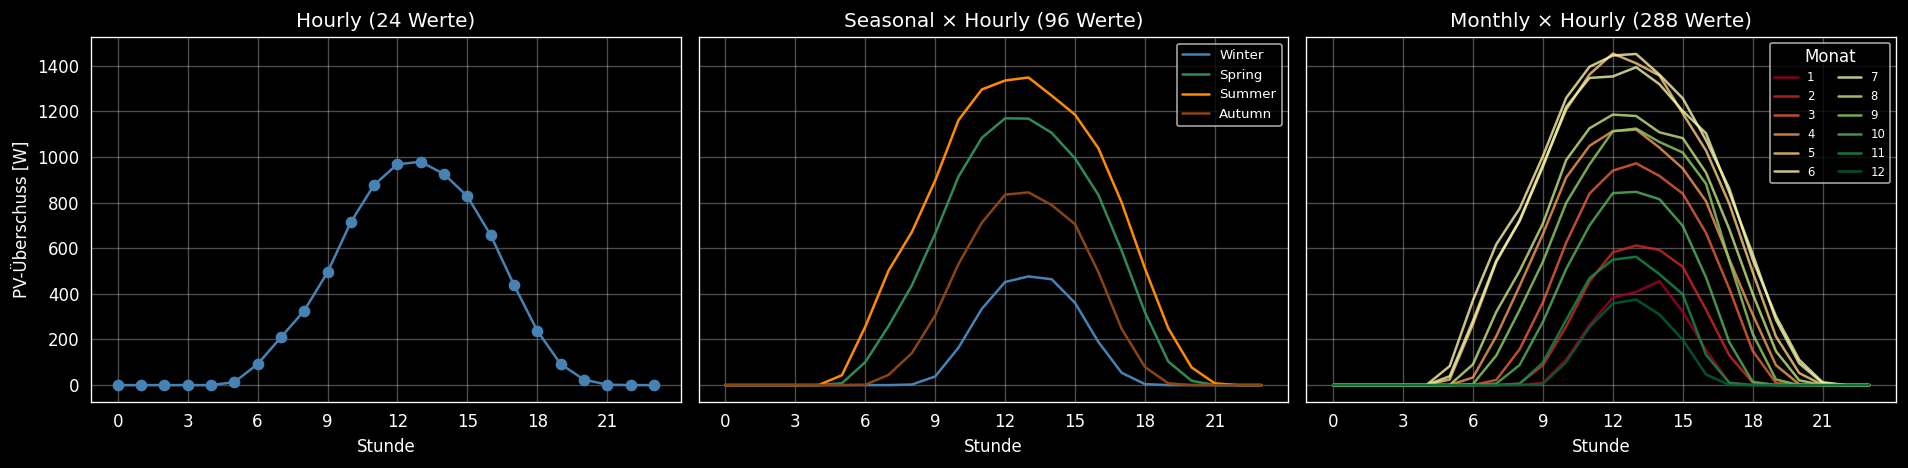

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Hourly
hourly_means.plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set(title="Hourly (24 Werte)", xlabel="Stunde", ylabel="PV-Überschuss [W]")
axes[0].set_xticks(range(0, 24, 3))

# Seasonal
for season, color in [("Winter", "steelblue"), ("Spring", "seagreen"),
                      ("Summer", "darkorange"), ("Autumn", "saddlebrown")]:
    if season in seasonal_means.index.get_level_values(0):
        seasonal_means[season].plot(ax=axes[1], label=season, color=color)
axes[1].set(title="Seasonal × Hourly (96 Werte)", xlabel="Stunde")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(fontsize=8)

# Monthly (subset for readability)
cmap = plt.cm.RdYlGn
for i, month in enumerate(range(1, 13)):
    if month in monthly_means.index.get_level_values(0):
        monthly_means[month].plot(ax=axes[2], color=cmap(i / 11),
                                   label=str(month), alpha=0.8)
axes[2].set(title="Monthly × Hourly (288 Werte)", xlabel="Stunde")
axes[2].set_xticks(range(0, 24, 3))
axes[2].legend(title="Monat", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 3 · Forecasts erstellen

In [5]:
def make_preds(fit_means, predict_fn, split_df, y_index):
    return predict_fn(fit_means, split_df).set_axis(y_index)

pred_hourly_val    = make_preds(hourly_means,   predict_climatological_mean,           val,  y_val.index)
pred_seasonal_val  = make_preds(seasonal_means, predict_climatological_mean_by_season, val,  y_val.index)
pred_monthly_val   = make_preds(monthly_means,  predict_climatological_mean_by_month,  val,  y_val.index)

pred_hourly_test   = make_preds(hourly_means,   predict_climatological_mean,           test, y_test.index)
pred_seasonal_test = make_preds(seasonal_means, predict_climatological_mean_by_season, test, y_test.index)
pred_monthly_test  = make_preds(monthly_means,  predict_climatological_mean_by_month,  test, y_test.index)

print("Forecasts erstellt.")

Forecasts erstellt.


## 4 · Evaluation – Vergleich der drei Varianten

In [6]:
MODELS = {
    "clim_hourly":   (pred_hourly_val,   pred_hourly_test),
    "clim_seasonal": (pred_seasonal_val, pred_seasonal_test),
    "clim_monthly":  (pred_monthly_val,  pred_monthly_test),
}

metrics_all = {}
for name, (pv, pt) in MODELS.items():
    metrics_all[name] = {
        "val":  evaluate(y_val,  pv, p_nom=P_NOM),
        "test": evaluate(y_test, pt, p_nom=P_NOM),
    }

KEY = ["rmse", "mae", "r2", "skill_mae", "ramp_mae"]

for split in ["val", "test"]:
    print(f"── {split.upper()} ─────────────────────────────────────")
    display(
        pd.DataFrame({m: metrics_all[m][split] for m in MODELS})
        .T[KEY].round(3)
    )

── VAL ─────────────────────────────────────


,rmse,mae,r2,skill_mae,ramp_mae
clim_hourly,339.024,217.098,0.553,-0.454,68.755
clim_seasonal,258.578,152.030,0.740,-0.015,69.234
clim_monthly,242.233,134.822,0.772,0.102,68.772


── TEST ─────────────────────────────────────


,rmse,mae,r2,skill_mae,ramp_mae
clim_hourly,340.774,215.377,0.539,-0.450,62.587
clim_seasonal,275.022,154.176,0.700,-0.043,60.703
clim_monthly,259.168,141.959,0.733,0.039,60.728


In [7]:
# Saisonale Metriken für das beste Modell (monthly)
seasonal_val_m  = evaluate_by_season(y_val,  pred_monthly_val,  p_nom=P_NOM)
seasonal_test_m = evaluate_by_season(y_test, pred_monthly_test, p_nom=P_NOM)

print("── clim_monthly – Val (nach Saison) ─────────────")
display(seasonal_val_m[["rmse", "mae", "r2", "skill_mae"]].round(3))
print("── clim_monthly – Test (nach Saison) ────────────")
display(seasonal_test_m[["rmse", "mae", "r2", "skill_mae"]].round(3))

── clim_monthly – Val (nach Saison) ─────────────


,rmse,mae,r2,skill_mae
Winter,153.613,61.165,0.361,0.273
Summer,274.659,169.298,0.786,0.205
Autumn,224.495,118.049,0.686,-0.073


── clim_monthly – Test (nach Saison) ────────────


,rmse,mae,r2,skill_mae
Winter,211.606,92.542,0.546,0.010
Spring,287.711,174.281,0.736,0.046
Summer,287.146,187.540,0.774,0.084


## 5 · Ergebnisse speichern

In [8]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for name, (pv, pt) in MODELS.items():
    sv = evaluate_by_season(y_val,  pv, p_nom=P_NOM)
    st = evaluate_by_season(y_test, pt, p_nom=P_NOM)
    payload = {
        "model":          name,
        "val":            metrics_all[name]["val"],
        "test":           metrics_all[name]["test"],
        "val_by_season":  sv.to_dict(orient="index"),
        "test_by_season": st.to_dict(orient="index"),
    }
    path = RESULTS_DIR / f"{name}.json"
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)
    print(f"Gespeichert: {path}")

# Alte einzelne climatology.json entfernen falls vorhanden
old = RESULTS_DIR / "climatology.json"
if old.exists():
    old.unlink()
    print(f"Entfernt (veraltet): {old}")

Gespeichert: ../results/naive/clim_hourly.json
Gespeichert: ../results/naive/clim_seasonal.json
Gespeichert: ../results/naive/clim_monthly.json
Entfernt (veraltet): ../results/naive/climatology.json
